# Tensor-Network Hybrid: Product-State Energy Filtering

This emerging workflow treats a simple product-state ansatz like a tiny tensor-network input, then applies a polynomial energy filter to improve its low-energy overlap. The same idea appears in hybrid tensor-network plus quantum spectral filtering proposals.

## Problem, QSVT Strategy, and Quantum Relevance

**System/problem.** This notebook studies a product-state variational ansatz for a small Ising Hamiltonian.

**QSVT implementation.** It applies a polynomial low-energy filter to improve the state energy. The matrices are deliberately small so the spectral rescaling, polynomial target, and validation quantities are visible in one executable notebook.

**Classical reference and quantum relevance.** Exact diagonalization validates the energy improvement and ground-state target. This illustrates a hybrid role for QSVT filters: refine a prepared state by suppressing high-energy components when the Hamiltonian can be block encoded.


## Variable definitions

- `H`: spin-chain Hamiltonian.
- `energies`, `vecs`: exact eigenvalues and eigenvectors.
- `theta`: single-qubit rotation angle used to build the product state.
- `single_site`: one-site state vector.
- `product_state`: unfiltered tensor-product trial state.
- `cutoff`: low-energy threshold.
- `scale`: spectral scale around the cutoff.
- `A`: rescaled Hamiltonian.
- `coeffs`: low-energy projector polynomial coefficients.
- `P_low`: polynomial low-energy projector.
- `filtered`: filtered and normalized state.
- `ground_vec`: exact ground-state vector.
- `initial_energy`, `filtered_energy`: energy expectations before and after filtering.
- `initial_overlap`, `filtered_overlap`: ground-state probabilities before and after filtering.
- `labels`, `fig`, `axes`, and similar names are plotting helpers.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from qsvt.design import design_projector_polynomial
from qsvt.hamiltonians import ising_hamiltonian
from qsvt.spectral import apply_polynomial_to_hermitian, eigh_hermitian

H = ising_hamiltonian(3, coupling=1.0, transverse_field=0.5)
energies, vecs = eigh_hermitian(H)

theta = 1.20
single_site = np.array([np.cos(theta / 2), np.sin(theta / 2)])
product_state = np.kron(np.kron(single_site, single_site), single_site)
product_state = product_state / np.linalg.norm(product_state)

cutoff = 0.5 * (energies[0] + energies[2])
scale = np.max(np.abs(cutoff - energies))
A = (cutoff * np.eye(H.shape[0]) - H) / scale
coeffs = design_projector_polynomial(gamma=0.18, degree=17)
P_low = apply_polynomial_to_hermitian(A, coeffs)

filtered = P_low @ product_state
filtered = filtered / np.linalg.norm(filtered)

ground_vec = vecs[:, 0]
initial_energy = np.real(np.vdot(product_state, H @ product_state))
filtered_energy = np.real(np.vdot(filtered, H @ filtered))
initial_overlap = abs(np.vdot(ground_vec, product_state)) ** 2
filtered_overlap = abs(np.vdot(ground_vec, filtered)) ** 2

print(f"Initial Energy [model energy units]: {initial_energy}")
print(f"Filtered Energy [model energy units]: {filtered_energy}")
print(f"Initial Overlap [probability]: {initial_overlap}")
print(f"Filtered Overlap [probability]: {filtered_overlap}")

Initial Energy [model energy units]: -1.6606649134095948
Filtered Energy [model energy units]: -2.3777913739261485
Initial Overlap [probability]: 0.651393401185215
Filtered Overlap [probability]: 0.8772155174329324


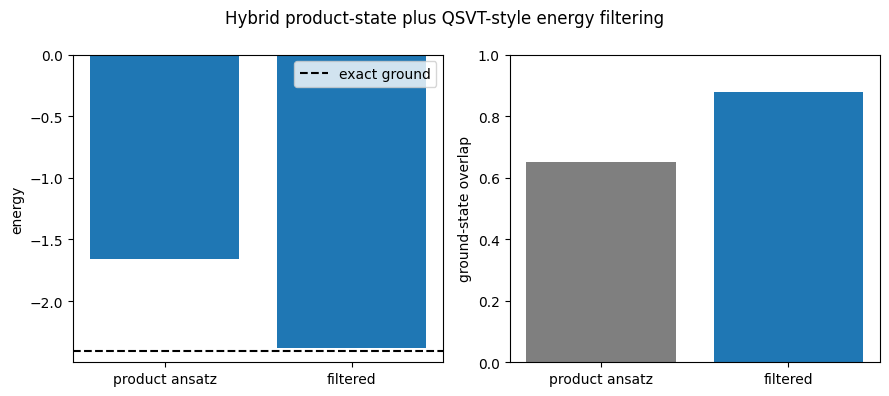

In [2]:
labels = ["product ansatz", "filtered"]
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].bar(labels, [initial_energy, filtered_energy])
axes[0].axhline(energies[0], color="black", linestyle="--", label="exact ground")
axes[0].set_ylabel("energy")
axes[0].legend()
axes[1].bar(labels, [initial_overlap, filtered_overlap], color=["tab:gray", "tab:blue"])
axes[1].set_ylabel("ground-state overlap")
axes[1].set_ylim(0, 1)
fig.suptitle("Hybrid product-state plus QSVT-style energy filtering")
plt.tight_layout()
plt.show()